In [2]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

import streamlit as st


In [3]:
url = r"C:\Users\dorice asami\OneDrive\Desktop\Health_n_fitness_analysis\health_fitness_dataset.csv"

df1= pd.read_csv(url)

In [4]:
df1.head(10)

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33
5,1,2024-01-10,56,F,165.3,54.9,HIIT,31,Medium,6.8,...,10,10202,2.2,19.6,69.5,110.7,72.9,NaN,Never,0.37
6,1,2024-01-11,56,F,165.3,55.2,Weight Training,97,High,12.4,...,8,5912,2.8,19.6,69.5,110.7,72.9,NaN,Never,0.51
7,1,2024-01-12,56,F,165.3,55.5,HIIT,70,Low,12.9,...,7,9477,1.6,19.6,69.5,110.7,72.9,NaN,Never,0.58
8,1,2024-01-17,56,F,165.3,55.7,HIIT,89,Medium,19.7,...,7,9710,3.3,19.6,69.5,110.7,72.9,NaN,Never,0.68
9,1,2024-01-18,56,F,165.3,56.0,Weight Training,115,Medium,12.8,...,3,7830,2.0,19.6,69.5,110.7,72.9,NaN,Never,0.82


In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   participant_id            687701 non-null  int64  
 1   date                      687701 non-null  object 
 2   age                       687701 non-null  int64  
 3   gender                    687701 non-null  object 
 4   height_cm                 687701 non-null  float64
 5   weight_kg                 687701 non-null  float64
 6   activity_type             687701 non-null  object 
 7   duration_minutes          687701 non-null  int64  
 8   intensity                 687701 non-null  object 
 9   calories_burned           687701 non-null  float64
 10  avg_heart_rate            687701 non-null  int64  
 11  hours_sleep               687701 non-null  float64
 12  stress_level              687701 non-null  int64  
 13  daily_steps               687701 non-null  i

# DATA CLEANUP
- check and handle missing values
- Convert Datatype of date and time to Date time
- create derived columns like BMI category

In [6]:
#convert to datetime datatype

df1['date']= pd.to_datetime(df1['date'])

df1.dtypes

participant_id                       int64
date                        datetime64[ns]
age                                  int64
gender                              object
height_cm                          float64
weight_kg                          float64
activity_type                       object
duration_minutes                     int64
intensity                           object
calories_burned                    float64
avg_heart_rate                       int64
hours_sleep                        float64
stress_level                         int64
daily_steps                          int64
hydration_level                    float64
bmi                                float64
resting_heart_rate                 float64
blood_pressure_systolic            float64
blood_pressure_diastolic           float64
health_condition                    object
smoking_status                      object
fitness_level                      float64
dtype: object

In [7]:
# fill Nan values on health conditions with Normal
df1['health_condition'] = df1['health_condition'].fillna('Normal')

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   participant_id            687701 non-null  int64         
 1   date                      687701 non-null  datetime64[ns]
 2   age                       687701 non-null  int64         
 3   gender                    687701 non-null  object        
 4   height_cm                 687701 non-null  float64       
 5   weight_kg                 687701 non-null  float64       
 6   activity_type             687701 non-null  object        
 7   duration_minutes          687701 non-null  int64         
 8   intensity                 687701 non-null  object        
 9   calories_burned           687701 non-null  float64       
 10  avg_heart_rate            687701 non-null  int64         
 11  hours_sleep               687701 non-null  float64       
 12  st

In [8]:
df1['participant_id'].nunique()

3000

In [9]:
#add column age group
bins = [18, 26, 41, 61, 100]
labels = ['18-25', '26-40', '41-60', '61+']
df1['age group'] = pd.cut(df1['age'], bins=bins, labels=labels, right=False)

In [10]:
df1['age group'].unique()

['41-60', '26-40', '18-25', '61+']
Categories (4, object): ['18-25' < '26-40' < '41-60' < '61+']

Descriptive Analysis
- Average, MAX, AND MIN  values


In [11]:

df1.describe().T

,count,mean,min,25%,50%,75%,max,std
participant_id,687701.0,1499.781828,1.0,749.0,1499.0,2249.0,3000.0,865.997215
date,687701,2024-06-16 18:44:21.629981952,2024-01-01 00:00:00,2024-03-21 00:00:00,2024-06-06 00:00:00,2024-09-11 00:00:00,2024-12-25 00:00:00,NaN
age,687701.0,41.658602,18.0,30.0,42.0,53.0,64.0,13.58177
height_cm,687701.0,168.587699,145.0,161.7,168.2,175.3,198.5,9.140811
weight_kg,687701.0,94.921981,45.3,78.2,94.6,110.5,188.4,22.461801
duration_minutes,687701.0,70.011671,20.0,45.0,70.0,95.0,120.0,29.147251
calories_burned,687701.0,15.381302,0.8,7.8,13.0,20.7,92.0,9.985552
avg_heart_rate,687701.0,131.454165,82.0,118.0,130.0,144.0,206.0,17.814744
hours_sleep,687701.0,7.048799,4.0,6.4,7.0,7.7,10.0,0.972068
stress_level,687701.0,5.252389,1.0,3.0,5.0,8.0,10.0,2.770029


- Min age is 18 while the highest is 64
- Min BMI is 14.2 while max is 38.8 - displays high chances that there are underweight and obese cases
- Average bmi is 22.7 - shows that most individuals are keeping fit
- Data derived from 3000 participants in a span of 1yr, 2024 Jan to Dec


# UNIVERIATE ANALYSIS

- High level view of participants by age, gender, BMI and calories burned

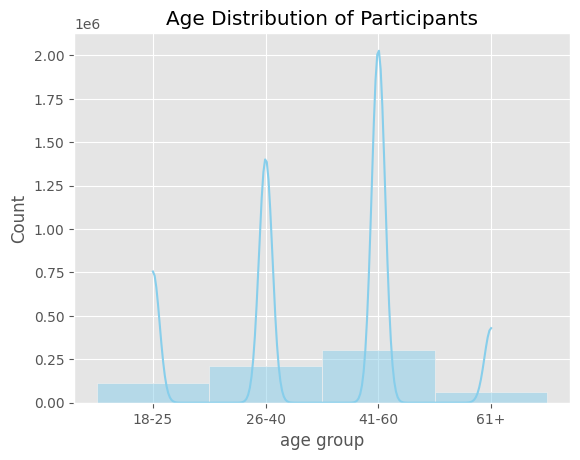

In [12]:
# plot participants age distribution
#plt.figure(figsize=(8,6))
sns.histplot(df1['age group'], kde=True, color='skyblue')
plt.title("Age Distribution of Participants")
plt.xlabel("age group")
plt.ylabel("Count")
plt.savefig("age_distribution _hist_plot.png")
plt.show()

- Most participants are of age group 50s


In [13]:
df1['gender'].unique()

array(['F', 'M', 'Other'], dtype=object)

In [14]:
gender_counts= df1['gender'].value_counts()

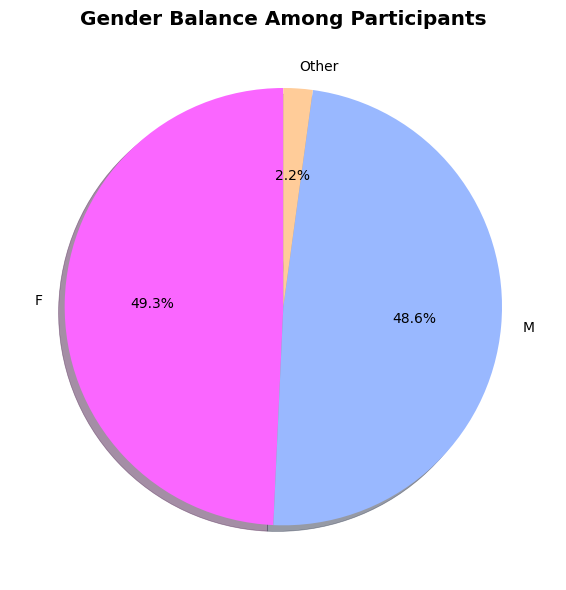

In [15]:
# plot of gender ratio
plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', shadow = True,
        startangle=90, colors=["#fa66ff","#99b8ff",'#ffcc99'])
plt.title("Gender Balance Among Participants", fontweight='bold')
plt.tight_layout()
plt.savefig("participants_gender_pie_chart.png")
plt.show()

- Female participants were slightly higher than the male ones

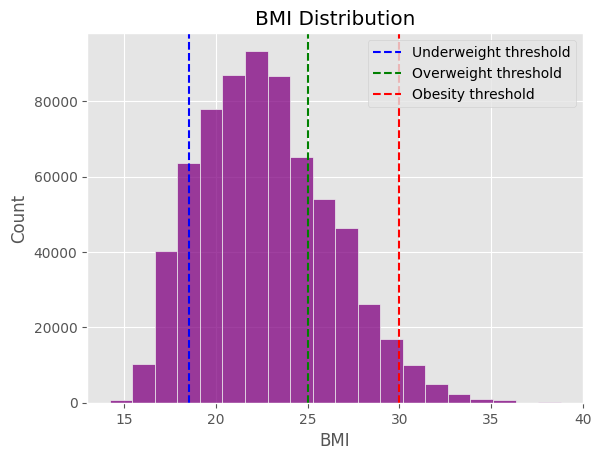

In [16]:
#bmi distribution
sns.histplot(df1['bmi'], bins= 20, color='purple')
plt.title("BMI Distribution")
plt.xlabel("BMI")

plt.axvline(18.5, color='blue', linestyle='--', label='Underweight threshold')
plt.axvline(25, color='green', linestyle='--', label='Overweight threshold')
plt.axvline(30, color='red', linestyle='--', label='Obesity threshold')
plt.legend()
plt.savefig("BMI_distribution _hist_plot.png")
plt.show()


- most participants have normal or slightly high BMI

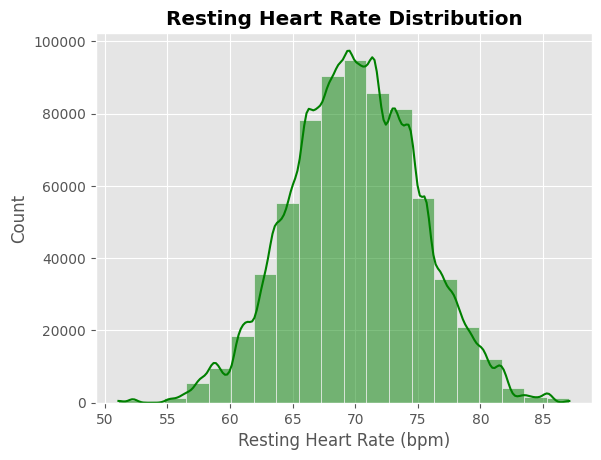

In [17]:
#distribution of cardiovascular health

sns.histplot(df1['resting_heart_rate'], bins=20, kde=True, color='green')
plt.title("Resting Heart Rate Distribution", fontweight= 'bold')
plt.xlabel("Resting Heart Rate (bpm)")
plt.savefig("Heart_Rate_distribution _hist_plot.png")
plt.show()

- resting heart rate is uniformly skewed
- most individuals have a resting heartrate of between 65 and 75 beats per minute; Averagely healthy adults

Distribution of Calories Burned

In [18]:
df1.columns


Index(['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg',
       'activity_type', 'duration_minutes', 'intensity', 'calories_burned',
       'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps',
       'hydration_level', 'bmi', 'resting_heart_rate',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'health_condition', 'smoking_status', 'fitness_level', 'age group'],
      dtype='object')

Participants who burned most calories throughout the period

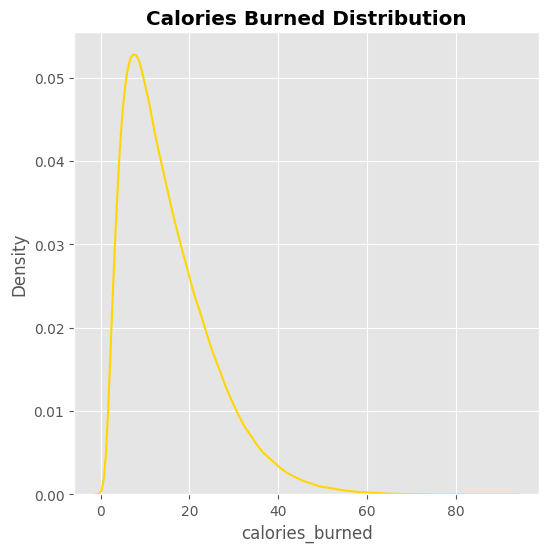

In [87]:
plt.figure(figsize=(6,6))
sns.kdeplot(df1['calories_burned'],color='gold')
plt.title("Calories Burned Distribution", fontweight= 'bold')
plt.savefig("calorie_dist_kde_plot.png")
plt.show()

- most participants burn moderate calories while a few burn more calories
- generally longer workouts yield high calories meaning most individuals exercise moderately

In [21]:
# Total vigorous activity per user
vigorous = df1.groupby('participant_id')['duration_minutes'].mean().reset_index()

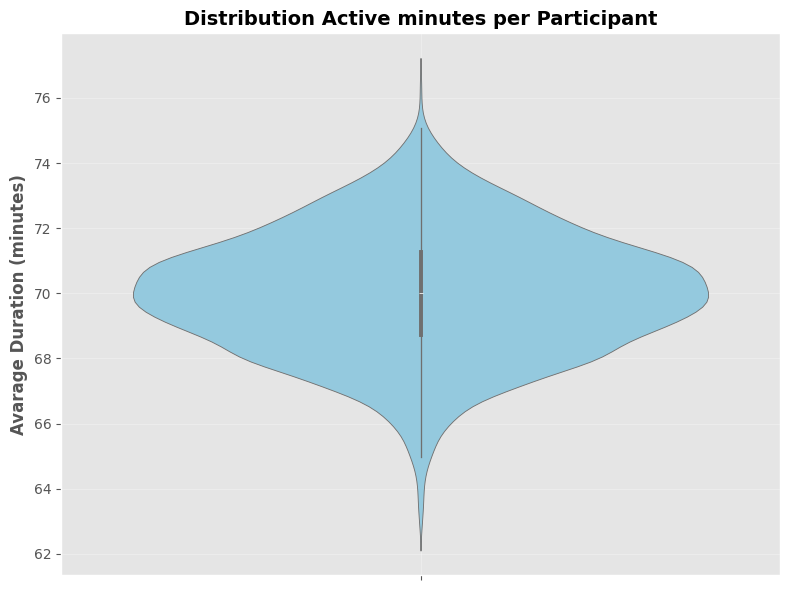

In [22]:
plt.figure(figsize=(8,6))
sns.violinplot(y=vigorous['duration_minutes'], color='skyblue', inner='box')
plt.title("Distribution Active minutes per Participant", fontweight='bold', fontsize=14)
plt.ylabel("Avarage Duration (minutes)", fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("AVG_active_mins _violin_plot.png")
plt.show()

- avarage activity duration is 70, 
- most participants spend 68 to 72 mins on activities

# BIVARIATE ANALYSIS
 - Observation of calories burn vs other variables
 - what exactly contributes to effective calorie burn? is it age, bmi, healthy conditions, smocking status or fitness level?

1. Calories burned vs BMI

C:\Users\dorice asami\AppData\Local\Temp\ipykernel_10988\1835891462.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='BMI_Category', y='calories_burned', data=df1, palette='viridis')


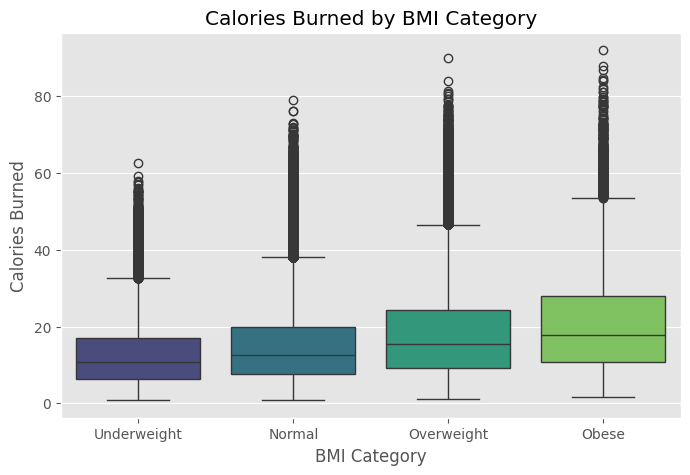

In [23]:
bins = [0, 18.5, 24.9, 29.9, 40]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df1['BMI_Category'] = pd.cut(df1['bmi'], bins=bins, labels=labels)

plt.figure(figsize=(8,5))
sns.boxplot(x='BMI_Category', y='calories_burned', data=df1, palette='viridis')
plt.title("Calories Burned by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Calories Burned")
plt.savefig("calorie_vs_bmi_box_plot.png")
plt.show()

- Obese participants tend to burn more calories than the rest, 
- the more body mass the more one is likey to burn calories even with minor physical excercise
- more outliers per BMI category


2. Activity type vs calories burned

In [24]:
df1['activity_type'].unique()

array(['Dancing', 'Swimming', 'Weight Training', 'HIIT', 'Running',
       'Walking', 'Tennis', 'Basketball', 'Yoga', 'Cycling'], dtype=object)

In [25]:
activity_calories= df1.groupby('activity_type')['calories_burned'].mean().reset_index().sort_values('calories_burned', ascending=False)

activity_calories = pd.DataFrame(activity_calories)

print(activity_calories)

     activity_type  calories_burned
3             HIIT        25.994067
4          Running        21.327712
1          Cycling        18.498666
0       Basketball        17.357854
6           Tennis        15.846564
5         Swimming        15.188164
8  Weight Training        13.040469
2          Dancing        11.990842
7          Walking         8.229493
9             Yoga         6.506351


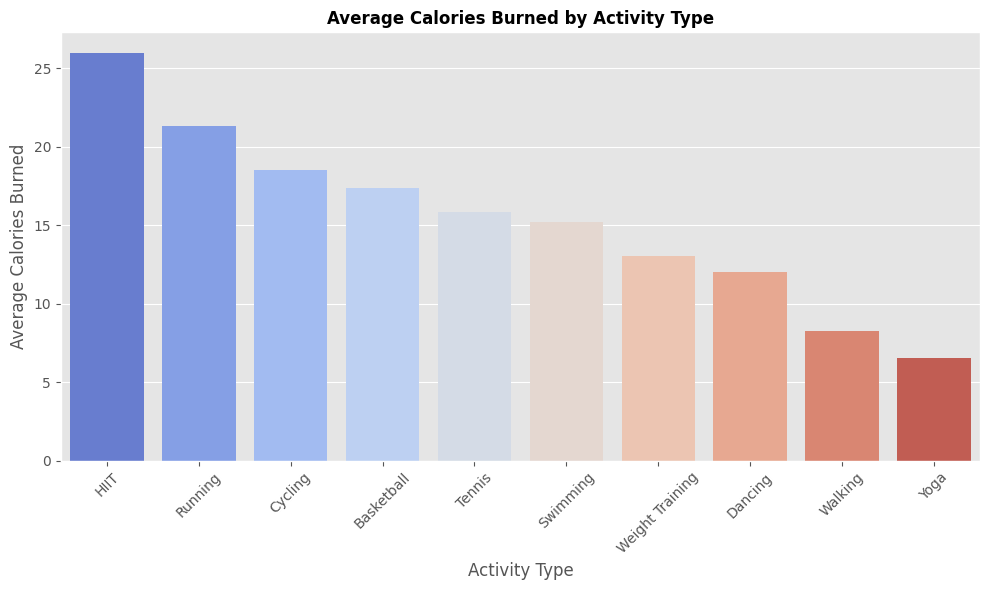

In [30]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=activity_calories,
    x='activity_type',
    y='calories_burned',
    hue='activity_type',       
    legend=False,             
    palette='coolwarm'
)

plt.title("Average Calories Burned by Activity Type",fontweight='bold', fontsize=12)
plt.xlabel("Activity Type")
plt.ylabel("Average Calories Burned")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("calorie_vs_activity_bar_plot.png")
plt.show()

- HIIT , Running and cycling have highest calories burn
- yoga has less calories burn

3. Calories burned vs sleep duration

C:\Users\dorice asami\AppData\Local\Temp\ipykernel_10988\2850609834.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


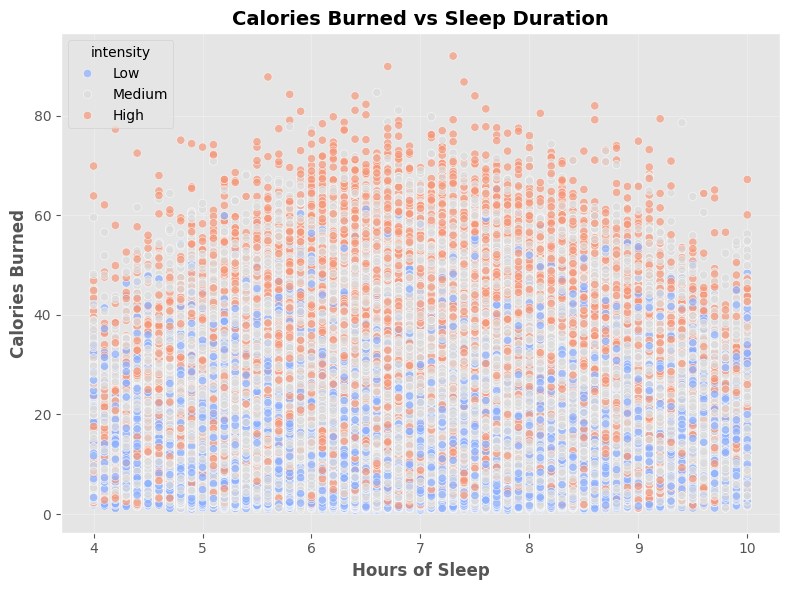

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df1,
    x='hours_sleep',
    y='calories_burned',
    hue='intensity',
    palette='coolwarm',
    alpha=0.7
)
plt.title("Calories Burned vs Sleep Duration", fontweight='bold', fontsize=14)
plt.xlabel("Hours of Sleep", fontweight='bold')
plt.ylabel("Calories Burned", fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("calorie_vs_sleep_scatter_plot.png")
plt.show()

- most indivivuals with high calorie burn tend to sleep between 6 to 8 hours

3. Age group vs Activity type

In [91]:
df1.columns

Index(['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg',
       'activity_type', 'duration_minutes', 'intensity', 'calories_burned',
       'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps',
       'hydration_level', 'bmi', 'resting_heart_rate',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'health_condition', 'smoking_status', 'fitness_level'],
      dtype='object')

C:\Users\dorice asami\AppData\Local\Temp\ipykernel_10988\1212156091.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df1.groupby(['age group', 'activity_type']).size().unstack(fill_value=0)


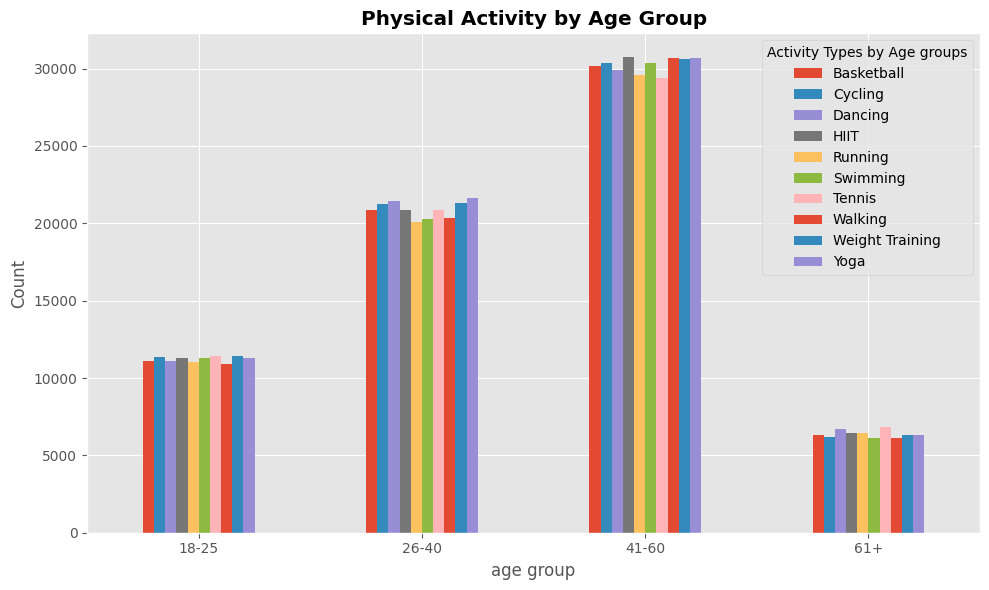

In [38]:
grouped_data = df1.groupby(['age group', 'activity_type']).size().unstack(fill_value=0)

grouped_data.plot(kind='bar', figsize=(10, 6))
plt.title('Physical Activity by Age Group', fontweight= 'bold')
plt.xlabel('age group')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Activity Types by Age groups')
plt.tight_layout()
plt.savefig("calorie_vs_activity_age_bar_plot.png")
plt.show()


- Participants in age group 41-60 engage in more activities
- HIIT,walking and weight training and yoga are the most common activities among age group 41-60

How fit are the individuals who burned more calories?

In [76]:
def categorize_fitness(level):
    if level <= 3:
        return 'Low'
    elif 3 < level <= 6:
        return 'Medium'
    else:
        return 'High'

df1['fitness_category'] = df1['fitness_level'].apply(categorize_fitness)

In [79]:
top_participants = (
    df1.groupby(['participant_id', 'fitness_category'])['calories_burned']
       .sum()
       .reset_index()
       .sort_values('calories_burned', ascending=False)
       .head(10)
)
print(top_participants)

      participant_id fitness_category  calories_burned
525              176             High           4806.6
2934             979             High           4572.6
5745            1916             High           4434.7
315              106             High           4378.5
453              152             High           4378.2
3402            1135             High           4349.1
6630            2211             High           4342.9
4455            1486             High           4304.2
6420            2141             High           4303.7
7365            2456             High           4210.3


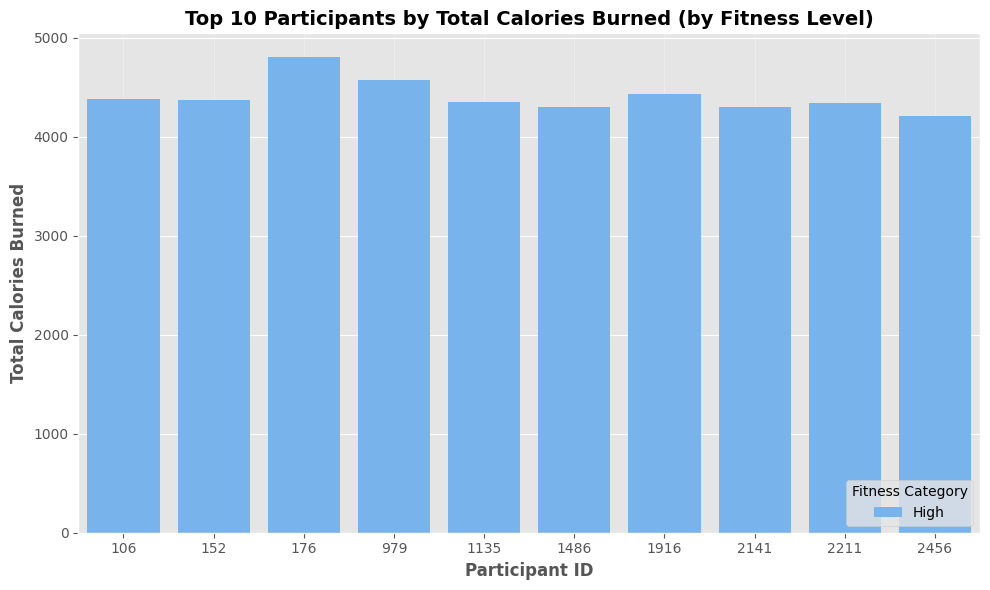

In [81]:
top_participants = (
    df1.groupby(['participant_id', 'fitness_category'])['calories_burned']
       .sum()
       .reset_index()
       .sort_values(by='calories_burned', ascending=False)
       .head(10)
)

palette = {'Low': '#ff9999', 'Medium': '#ffcc66', 'High': '#66b3ff'}

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_participants,
    y='calories_burned',
    x='participant_id',
    hue='fitness_category',
    palette=palette
)

plt.title("Top 10 Participants by Total Calories Burned (by Fitness Level)",
          fontsize=14, fontweight='bold')
plt.xlabel("Participant ID",fontweight='bold')
plt.ylabel("Total Calories Burned", fontweight='bold')
plt.legend(title="Fitness Category", loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("calorie_vs_fitness_participant_bar_plot.png")
plt.show()

- individuals who burned most calories had high fitness levels

4. Calories burned vs smocking status

In [63]:
df1['smoking_status'].unique()

array(['Never', 'Current', 'Former'], dtype=object)

C:\Users\dorice asami\AppData\Local\Temp\ipykernel_10988\4081210152.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


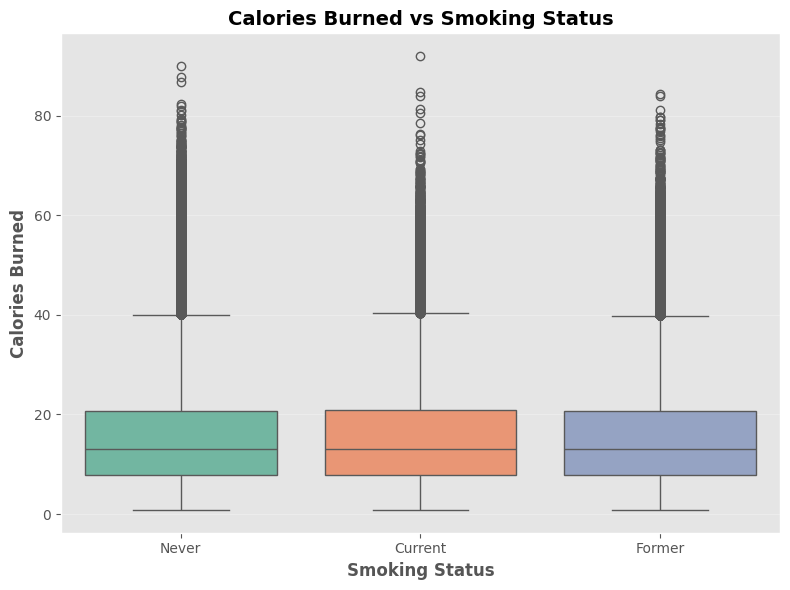

In [64]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df1,
    x='smoking_status',
    y='calories_burned',
    palette='Set2'
)

plt.title("Calories Burned vs Smoking Status", fontweight='bold', fontsize=14)
plt.xlabel("Smoking Status", fontweight='bold')
plt.ylabel("Calories Burned", fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("calorie_vs_smocking_box_plot.png")
plt.show()

- smocking status does not influence calories burned 

# MULTIVARIATE ANALYSIS

calories burns vs smoking status and activity type

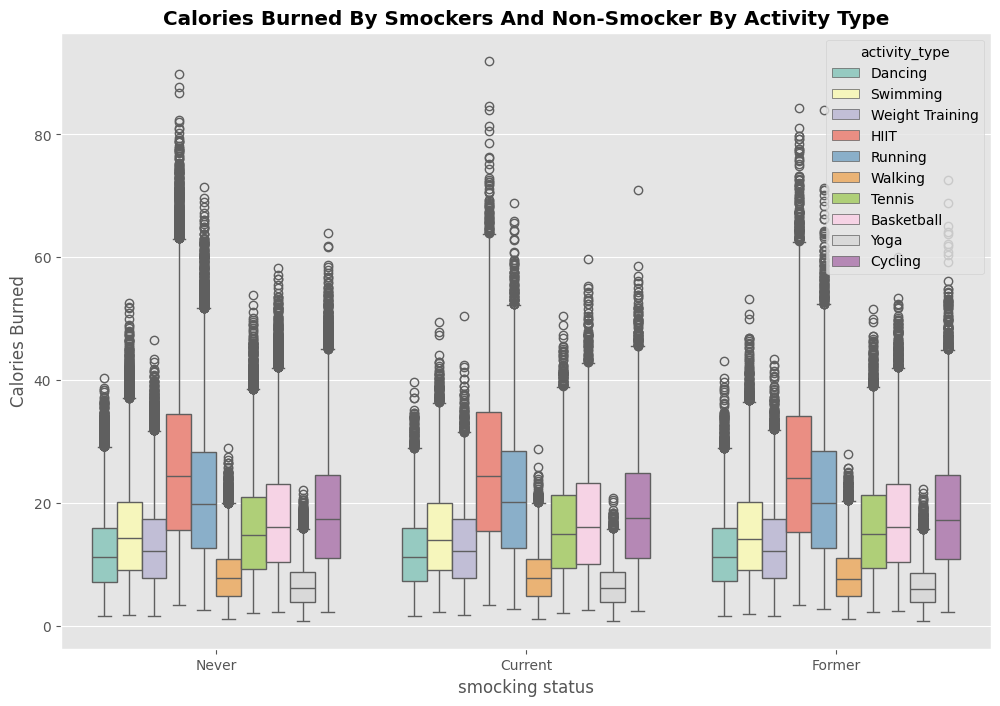

In [65]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df1, x='smoking_status', y='calories_burned', hue='activity_type', palette='Set3')
plt.title("Calories Burned By Smockers And Non-Smocker By Activity Type",fontweight='bold')
plt.xlabel("smocking status")
plt.ylabel("Calories Burned")
plt.savefig("calorie_vs_smocking_vs_activity_box_plot.png")
plt.show()

- Both smocking groups are seen to burn similar levels of calories per activity type


Calories burned vs duration in minutes and activity intensity


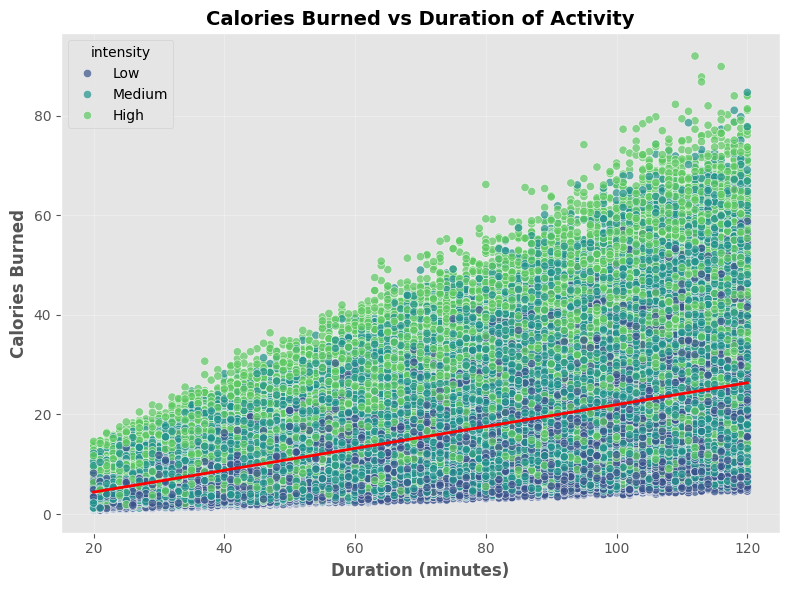

In [66]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df1,
    x='duration_minutes',
    y='calories_burned',
    hue='intensity',  
    palette='viridis',
    alpha=0.7
)
sns.regplot(
    data=df1,
    x='duration_minutes',
    y='calories_burned',
    scatter=False,
    color='red',
    line_kws={'lw':2}
)

plt.title("Calories Burned vs Duration of Activity", fontweight='bold', fontsize=14)
plt.xlabel("Duration (minutes)", fontweight='bold')
plt.ylabel("Calories Burned", fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("calorie_vs_duration_vs intensity_scatter_plot.png")
plt.show()

- calories burned tend to rise and duration of activity increases
- high intensity activities burn more calories compared to low intensity ones
- A balanced training plan might combine moderate duration with higher intensity for optimal calorie expenditure.

Calories Burned,smocking status and Activities

Text(0, 0.5, 'Calories Burned')

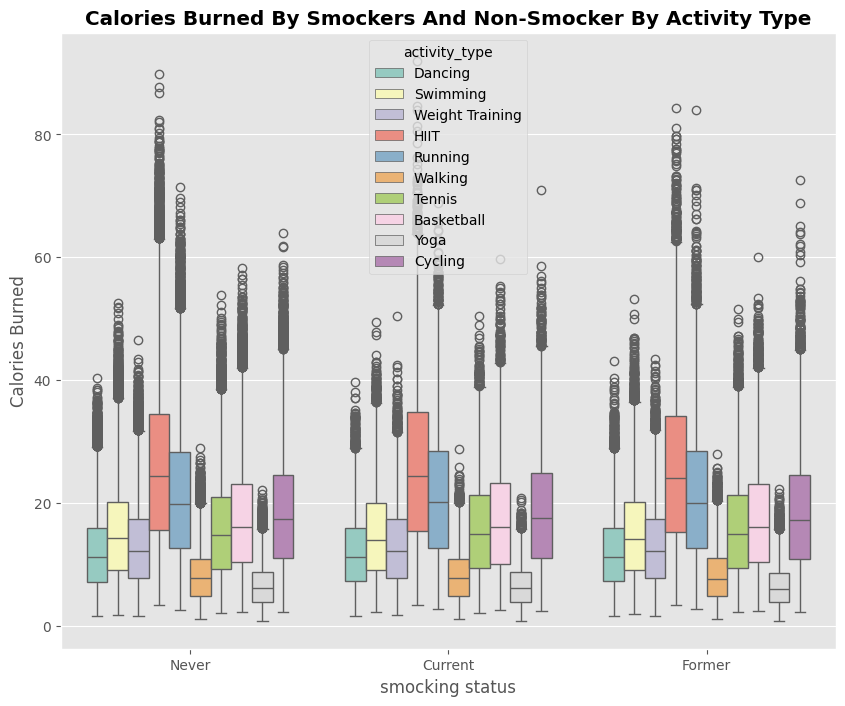

In [67]:

plt.figure(figsize=(10,8))
sns.boxplot(data=df1, x='smoking_status', y='calories_burned', hue='activity_type', palette='Set3')
plt.title("Calories Burned By Smockers And Non-Smocker By Activity Type",fontweight='bold')
plt.xlabel("smocking status")
plt.ylabel("Calories Burned")

 - Both smocking groups are seen to burn similar levels of calories per activity type

Examine how Calories Burned varies by participants with different Health conditions on different activitiy types

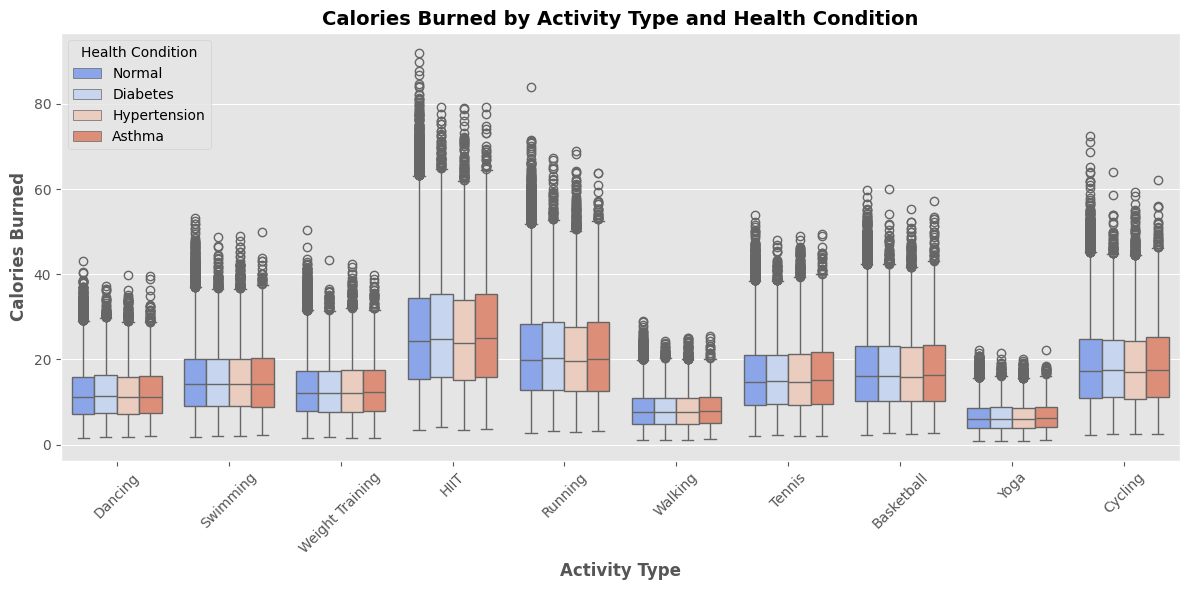

In [68]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df1,
    x='activity_type',
    y='calories_burned',
    hue='health_condition',
    palette='coolwarm'
)
plt.title("Calories Burned by Activity Type and Health Condition", fontweight='bold', fontsize=14)
plt.xlabel("Activity Type", fontweight='bold')
plt.ylabel("Calories Burned", fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title="Health Condition")
plt.tight_layout()
plt.savefig("calorie_vs_activity_healthcondition_box_plot.png")
plt.show()


- Normal participants burn more calories than ones with health conditions
- people with health conditions can equally participate in physical activities

Calories burned, BMI and activity type

In [69]:
df1['bmi_category'] = pd.cut(
    df1['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

df1['bmi_category'].unique()

['Normal', 'Overweight', 'Underweight', 'Obese']
Categories (4, object): ['Underweight' < 'Normal' < 'Overweight' < 'Obese']

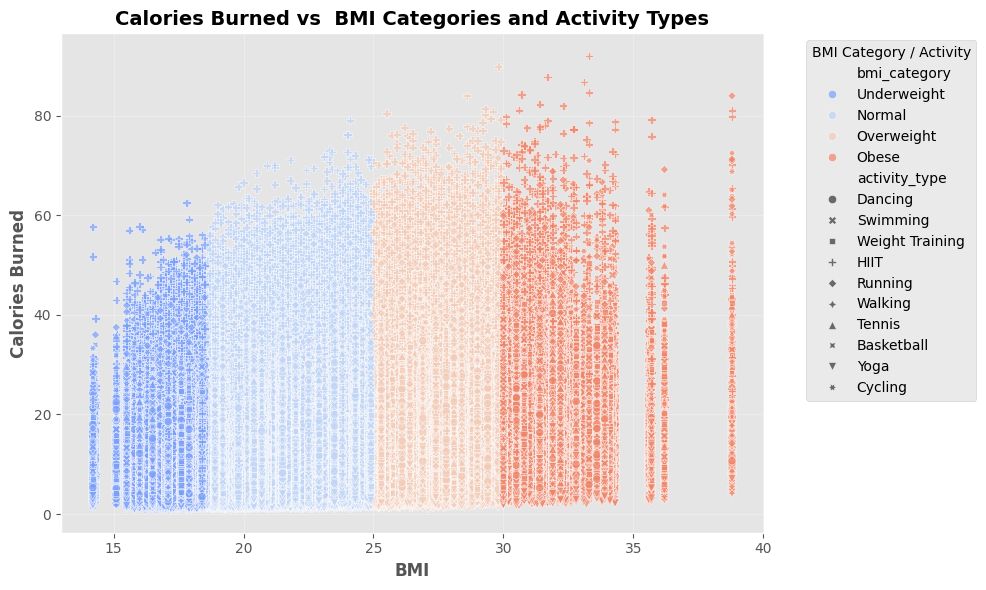

In [70]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df1,
    x='bmi',
    y='calories_burned',
    hue='bmi_category',
    style='activity_type',
    palette='coolwarm',
    alpha=0.7
)

plt.title("Calories Burned vs  BMI Categories and Activity Types", fontweight='bold', fontsize=14)
plt.xlabel("BMI", fontweight='bold')
plt.ylabel("Calories Burned", fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='BMI Category / Activity')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("calorie_vs_activity_bmi_scatter_plot.png")
plt.show()

- Overweight and obese individuals tend to burn more calories than the rest; big body size require more energy to move.
- underweight individuals have fewer calories burned due to lower mass
- Normal-weight individuals might show more consistent calorie ranges across activities, implying efficient energy usage.

Does mental wellness influence physical activity?

- Stress levels vs daily steps vs calories burned

In [71]:
df1['stress_category'].value_counts()

stress_category
Low     365254
High    322447
Name: count, dtype: int64

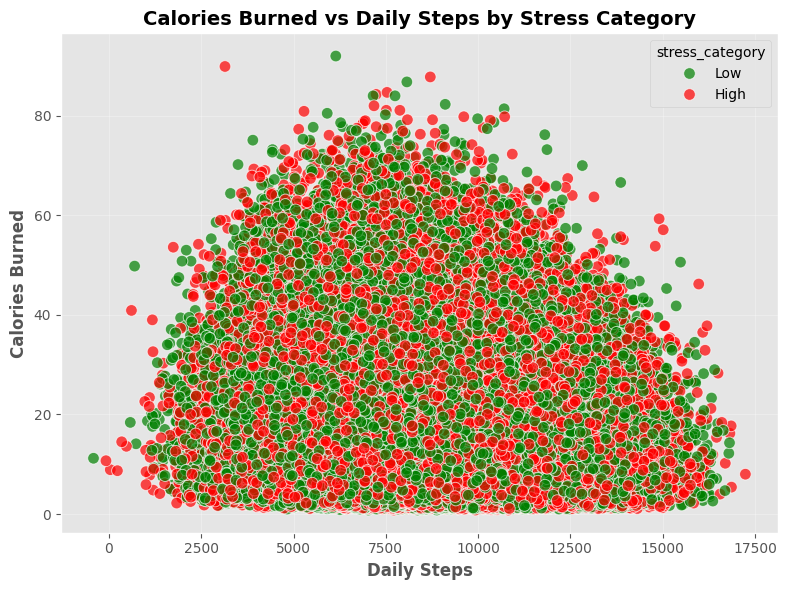

In [72]:
df1['stress_category'] = df1['stress_level'].apply(lambda x: 'High' if x >= 6 else 'Low')

# Create the plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df1,
    x='daily_steps',
    y='calories_burned',
    hue='stress_category',
    palette={'High':'red', 'Low':'green'},
    alpha=0.7,
    s=70
)

plt.title("Calories Burned vs Daily Steps by Stress Category", fontsize=14, fontweight='bold')
plt.xlabel("Daily Steps", fontweight='bold')
plt.ylabel("Calories Burned", fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("calorie_vs_steps_stress_scatter_plot.png")
plt.show()

- Calories burned and daily steps taken are fairly influenced by stress levels
- Both high and low stressed individuals take same number of stress hence same calories burn
- stressed individuals are seen having less than 2500 steps


Calorie burned vs age and gender

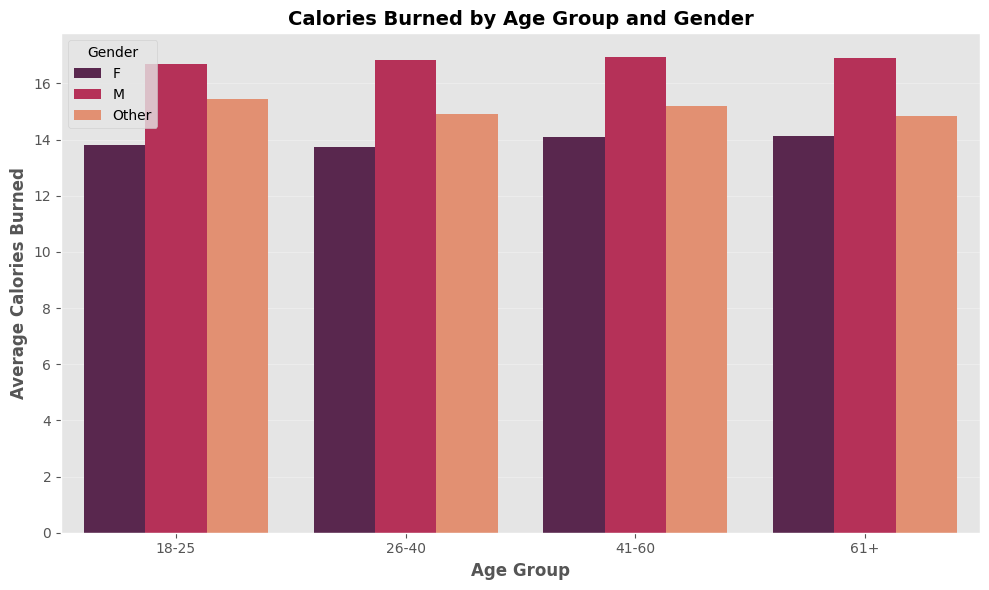

In [73]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df1,
    x='age group',
    y='calories_burned',
    hue='gender',
    palette='rocket',
    errorbar =None
)

plt.title("Calories Burned by Age Group and Gender", fontweight='bold', fontsize=14)
plt.xlabel("Age Group", fontweight='bold')
plt.ylabel("Average Calories Burned", fontweight='bold')
plt.legend(title='Gender')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("calorie_vs_age_gender_bar_plot.png")
plt.show()

- Male participants have relatively high calorie burn compared to female
- Differences between genders could be linked to average workout duration
- calorie burn is not influenced by age;
